# 09 — Statistická Analýza Výsledků

Finální statistická validace:
- **Část A (M3/S1):** Bootstrap CI a permutační testy pro LLM benchmark
- **Část B (M1/S1):** Vliv POS filtru na výkon unsupervised modelů (Kruskal-Wallis, Mann-Whitney U)

In [3]:
import sys
sys.path.append('..')

import pandas as pd
import os
import numpy as np
from scipy import stats
from sklearn.metrics import average_precision_score, f1_score

# Auto-reload modules for development
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Add src to path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

from config import *
from evaluation import *
import visualization 

# Sjednocený vizuální styl
visualization.setup_style()

print("✅ Importy načteny.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Importy načteny.


## 1. Načtení dat

In [4]:
pred_path = RESULTS_DIR / "M3_S1_LLM_predictions.csv"
df = pd.read_csv(pred_path)

# Kontrola klíčových sloupců
required_cols = ['pred_gemma-3-27b_zeroshot', 'pred_gemma-3-27b_fewshot', 'true_label', 'pos']
for col in required_cols:
    assert col in df.columns, f"Chybí sloupec: {col}"

print(f"✅ Načteno {len(df)} tokenů z {pred_path.name}")
print(f"   Sloupce: {list(df.columns)}")
print(f"   Distribuce true_label: {df['true_label'].value_counts().to_dict()}")

✅ Načteno 1246 tokenů z M3_S1_LLM_predictions.csv
   Sloupce: ['document_id', 'sentence_id', 'token_id', 'form', 'pos', 'true_label', 'sentence_context', 'pred_gemma-3-27b_zeroshot', 'pred_gemma-3-27b_fewshot']
   Distribuce true_label: {0: 1185, 1: 61}


## 2. Post-Hoc Filtrace (Masky)

- **none**: Všechny tokeny (žádná filtrace)
- **aggressive**: Pouze content words (NOUN, ADJ, VERB, ADV)

In [5]:
mask_none = pd.Series([True] * len(df))
mask_aggressive = df['pos'].isin(POS_ALLOWED_AGGRESSIVE)

filters = {
    'none': mask_none,
    'aggressive': mask_aggressive,
}

for name, mask in filters.items():
    subset = df[mask]
    print(f"Filtr '{name}': {mask.sum()} tokenů, L1={subset['true_label'].sum():.0f}, L0={len(subset) - subset['true_label'].sum():.0f}")

Filtr 'none': 1246 tokenů, L1=61, L0=1185
Filtr 'aggressive': 741 tokenů, L1=46, L0=695


## 3. Bootstrap CI (AUPRC)

95% interval spolehlivosti pro AUPRC pomocí bootstrap resamplingu (1000 iterací).

In [6]:
bootstrap_results = []

strategies = {
    'Zero-Shot': 'pred_gemma-3-27b_zeroshot',
    'Few-Shot': 'pred_gemma-3-27b_fewshot',
}

for filter_name, mask in filters.items():
    subset = df[mask]
    y_true = subset['true_label'].values
    
    for strat_name, col in strategies.items():
        y_pred = subset[col].values
        
        auprc = average_precision_score(y_true, y_pred)
        ci_low, ci_high = calculate_bootstrap_ci(y_true, y_pred, average_precision_score, n_bootstraps=1000)
        
        print(f"Gemma ({strat_name}, {filter_name}) AUPRC: {auprc:.4f} [95% CI: {ci_low:.4f}, {ci_high:.4f}]")
        
        bootstrap_results.append({
            'Model': 'Gemma-3-27B',
            'Strategy': strat_name,
            'Filter': filter_name,
            'AUPRC': round(auprc, 4),
            'CI_Low': round(ci_low, 4),
            'CI_High': round(ci_high, 4),
        })

df_bootstrap = pd.DataFrame(bootstrap_results)
df_bootstrap

Gemma (Zero-Shot, none) AUPRC: 0.0902 [95% CI: 0.0641, 0.1177]
Gemma (Few-Shot, none) AUPRC: 0.1025 [95% CI: 0.0734, 0.1372]
Gemma (Zero-Shot, aggressive) AUPRC: 0.1297 [95% CI: 0.0904, 0.1702]
Gemma (Few-Shot, aggressive) AUPRC: 0.1520 [95% CI: 0.1051, 0.2022]


,Model,Strategy,Filter,AUPRC,CI_Low,CI_High
0,Gemma-3-27B,Zero-Shot,none,0.0902,0.0641,0.1177
1,Gemma-3-27B,Few-Shot,none,0.1025,0.0734,0.1372
2,Gemma-3-27B,Zero-Shot,aggressive,0.1297,0.0904,0.1702
3,Gemma-3-27B,Few-Shot,aggressive,0.1520,0.1051,0.2022


## 4. Permutační testy (Statistická signifikance)

Párový permutační test: **H₀**: Few-Shot a Zero-Shot mají stejný AUPRC. **H₁**: Few-Shot je lepší.

In [7]:
perm_results = []

for filter_name, mask in filters.items():
    subset = df[mask]
    y_true = subset['true_label'].values
    y_fewshot = subset['pred_gemma-3-27b_fewshot'].values
    y_zeroshot = subset['pred_gemma-3-27b_zeroshot'].values
    
    # Few-Shot vs Zero-Shot
    p_value = permutation_test(y_true, y_fewshot, y_zeroshot, average_precision_score, n_permutations=10000)
    
    auprc_fs = average_precision_score(y_true, y_fewshot)
    auprc_zs = average_precision_score(y_true, y_zeroshot)
    
    sig = "✅ ANO" if p_value < 0.05 else "❌ NE"
    print(f"[{filter_name}] Few-Shot ({auprc_fs:.4f}) vs Zero-Shot ({auprc_zs:.4f}): p={p_value:.4f} → Signifikantní: {sig}")
    
    perm_results.append({
        'Comparison': 'Few-Shot vs Zero-Shot',
        'Filter': filter_name,
        'Metric': 'AUPRC',
        'Score_Model1': round(auprc_fs, 4),
        'Score_Model2': round(auprc_zs, 4),
        'Diff': round(auprc_fs - auprc_zs, 4),
        'p_value': round(p_value, 4),
        'Significant (α=0.05)': p_value < 0.05,
    })

    # Few-Shot vs Dummy (Dummy predikuje vždy prevalenci třídy 1)
    prevalence = y_true.mean()
    y_dummy = np.full_like(y_fewshot, fill_value=prevalence)
    
    p_value_dummy = permutation_test(y_true, y_fewshot, y_dummy, average_precision_score, n_permutations=10000)
    auprc_dummy = average_precision_score(y_true, y_dummy)
    
    sig_dummy = "✅ ANO" if p_value_dummy < 0.05 else "❌ NE"
    print(f"[{filter_name}] Few-Shot ({auprc_fs:.4f}) vs Dummy ({auprc_dummy:.4f}): p={p_value_dummy:.4f} → Signifikantní: {sig_dummy}")
    
    perm_results.append({
        'Comparison': 'Few-Shot vs Dummy',
        'Filter': filter_name,
        'Metric': 'AUPRC',
        'Score_Model1': round(auprc_fs, 4),
        'Score_Model2': round(auprc_dummy, 4),
        'Diff': round(auprc_fs - auprc_dummy, 4),
        'p_value': round(p_value_dummy, 4),
        'Significant (α=0.05)': p_value_dummy < 0.05,
    })
    print()

df_perm = pd.DataFrame(perm_results)
df_perm

[none] Few-Shot (0.1025) vs Zero-Shot (0.0902): p=0.0130 → Signifikantní: ✅ ANO
[none] Few-Shot (0.1025) vs Dummy (0.0490): p=0.0016 → Signifikantní: ✅ ANO

[aggressive] Few-Shot (0.1520) vs Zero-Shot (0.1297): p=0.0030 → Signifikantní: ✅ ANO
[aggressive] Few-Shot (0.1520) vs Dummy (0.0621): p=0.0026 → Signifikantní: ✅ ANO



,Comparison,Filter,Metric,Score_Model1,Score_Model2,Diff,p_value,Significant (α=0.05)
0,Few-Shot vs Zero-Shot,none,AUPRC,0.1025,0.0902,0.0124,0.0130,True
1,Few-Shot vs Dummy,none,AUPRC,0.1025,0.0490,0.0536,0.0016,True
2,Few-Shot vs Zero-Shot,aggressive,AUPRC,0.1520,0.1297,0.0223,0.0030,True
3,Few-Shot vs Dummy,aggressive,AUPRC,0.1520,0.0621,0.0899,0.0026,True


## 5. Export výsledků

In [8]:
# Export Bootstrap CI
bootstrap_path = RESULTS_DIR / "M3_S1_Bootstrap_CI.csv"
df_bootstrap.to_csv(bootstrap_path, index=False)
print(f"✅ Bootstrap CI uloženy: {bootstrap_path.name}")

# Export Permutační testy
perm_path = RESULTS_DIR / "M3_S1_Permutation_Tests.csv"
df_perm.to_csv(perm_path, index=False)
print(f"✅ Permutační testy uloženy: {perm_path.name}")

# Souhrnná tabulka
print("\n" + "="*80)
print("SOUHRNNÁ TABULKA STATISTICKÉ ANALÝZY")
print("="*80)
print("\n--- Bootstrap 95% CI (AUPRC) ---")
print(df_bootstrap.to_string(index=False))
print("\n--- Permutační testy ---")
print(df_perm.to_string(index=False))

✅ Bootstrap CI uloženy: M3_S1_Bootstrap_CI.csv
✅ Permutační testy uloženy: M3_S1_Permutation_Tests.csv

SOUHRNNÁ TABULKA STATISTICKÉ ANALÝZY

--- Bootstrap 95% CI (AUPRC) ---
      Model  Strategy     Filter  AUPRC  CI_Low  CI_High
Gemma-3-27B Zero-Shot       none 0.0902  0.0641   0.1177
Gemma-3-27B  Few-Shot       none 0.1025  0.0734   0.1372
Gemma-3-27B Zero-Shot aggressive 0.1297  0.0904   0.1702
Gemma-3-27B  Few-Shot aggressive 0.1520  0.1051   0.2022

--- Permutační testy ---
           Comparison     Filter Metric  Score_Model1  Score_Model2   Diff  p_value  Significant (α=0.05)
Few-Shot vs Zero-Shot       none  AUPRC        0.1025        0.0902 0.0124   0.0130                  True
    Few-Shot vs Dummy       none  AUPRC        0.1025        0.0490 0.0536   0.0016                  True
Few-Shot vs Zero-Shot aggressive  AUPRC        0.1520        0.1297 0.0223   0.0030                  True
    Few-Shot vs Dummy aggressive  AUPRC        0.1520        0.0621 0.0899   0.0026       

---
# Část B: Vliv POS filtru na výkon modelů (M1/S1)

Testujeme hypotézu: **Má typ POS filtrace (aggressive / mild / none) statisticky signifikantní vliv na AUPRC unsupervised modelů?**

## 6. Načtení M1/S1 výsledků

In [9]:
# Načtení M1/S1 výsledků (unsupervised modely s POS filtrací)
df_m1 = pd.read_csv(RESULTS_DIR / "M1_S1_experiment_results_v3_08-02.csv")

print(f"✅ Načteno {len(df_m1)} řádků z M1_S1_experiment_results_v3_08-02.csv")
print(f"   Sloupce: {list(df_m1.columns)}")
print(f"   Scénáře: {df_m1['scenario'].unique()}")
print(f"   Filtry:  {df_m1['filter'].unique()}")
print(f"   Modely:  {df_m1['model'].unique()}")
print()

# Základní statistiky AUPRC podle filtru
stats_by_filter = df_m1.groupby('filter')['test_auprc'].agg(['mean', 'median', 'std', 'count'])
stats_by_filter.columns = ['Mean AUPRC', 'Median AUPRC', 'Std AUPRC', 'N']
print("--- Deskriptivní statistiky (test AUPRC) podle filtru ---")
stats_by_filter

✅ Načteno 211 řádků z M1_S1_experiment_results_v3_08-02.csv
   Sloupce: ['scenario', 'filter', 'model', 'params', 'val_f1', 'val_threshold', 'test_f1', 'test_precision', 'test_recall', 'test_roc_auc', 'test_auprc']
   Scénáře: ['baseline' 'robustness']
   Filtry:  ['aggressive' 'mild' 'none']
   Modely:  ['Mahalanobis' 'IsolationForest' 'OCSVM']

--- Deskriptivní statistiky (test AUPRC) podle filtru ---


,Mean AUPRC,Median AUPRC,Std AUPRC,N
filter,,,,
aggressive,0.085112,0.080977,0.027093,71
mild,0.083555,0.080766,0.024926,70
none,0.068698,0.054608,0.031715,70


## 7. Vizualizace — Distribuce výkonu podle filtru

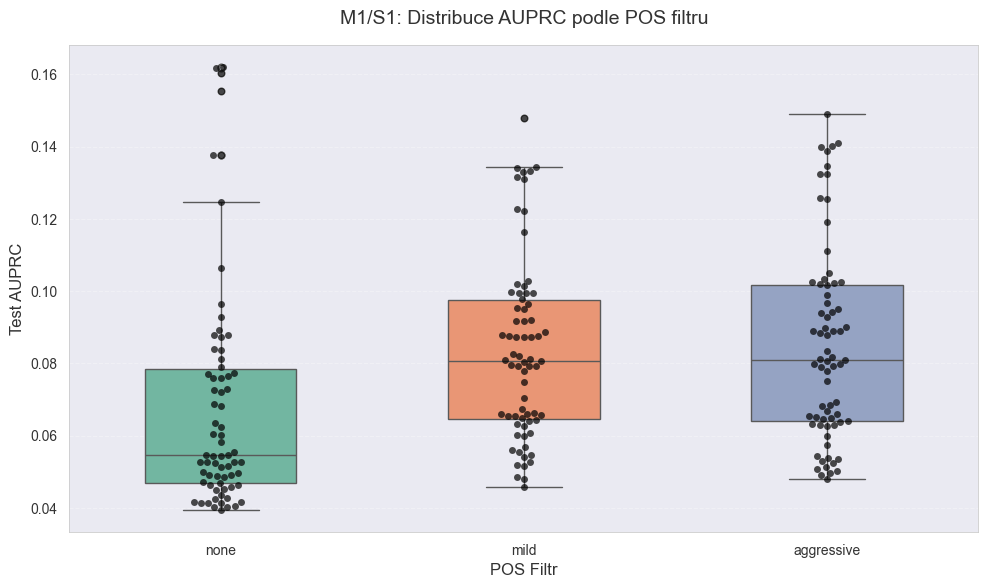

In [10]:
filter_order = ['none', 'mild', 'aggressive']

# --- AUPRC Boxplot ---
visualization.plot_filter_boxplot(
    df_m1, metric_col='test_auprc', filter_col='filter',
    filter_order=filter_order,
    title='M1/S1: Distribuce AUPRC podle POS filtru',
    ylabel='Test AUPRC',
    save_path=RESULTS_DIR / "M1_S1_Filter_AUPRC_Boxplot.png"
)

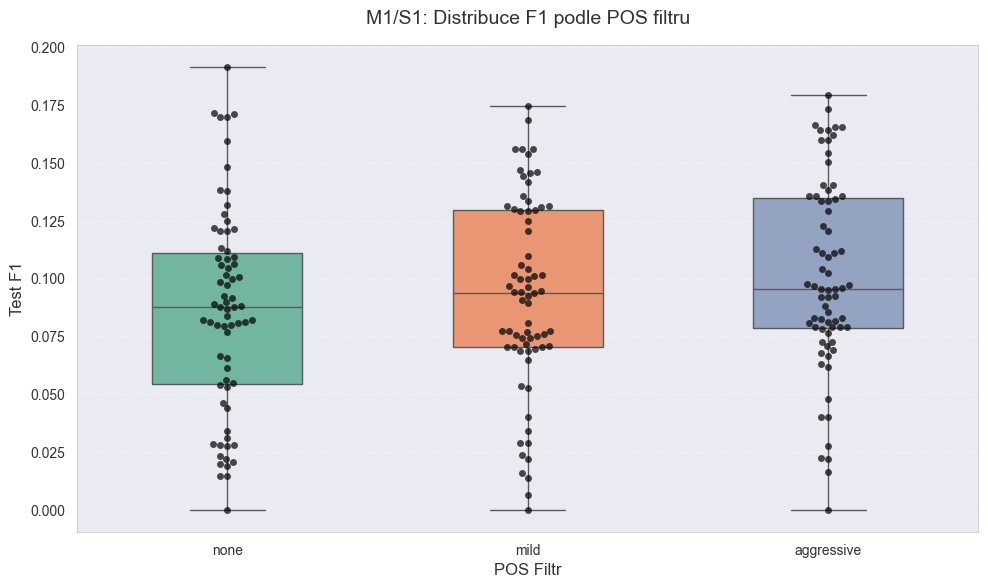

In [11]:
# --- F1 Boxplot ---
visualization.plot_filter_boxplot(
    df_m1, metric_col='test_f1', filter_col='filter',
    filter_order=filter_order,
    title='M1/S1: Distribuce F1 podle POS filtru',
    ylabel='Test F1',
    save_path=RESULTS_DIR / "M1_S1_Filter_F1_Boxplot.png"
)

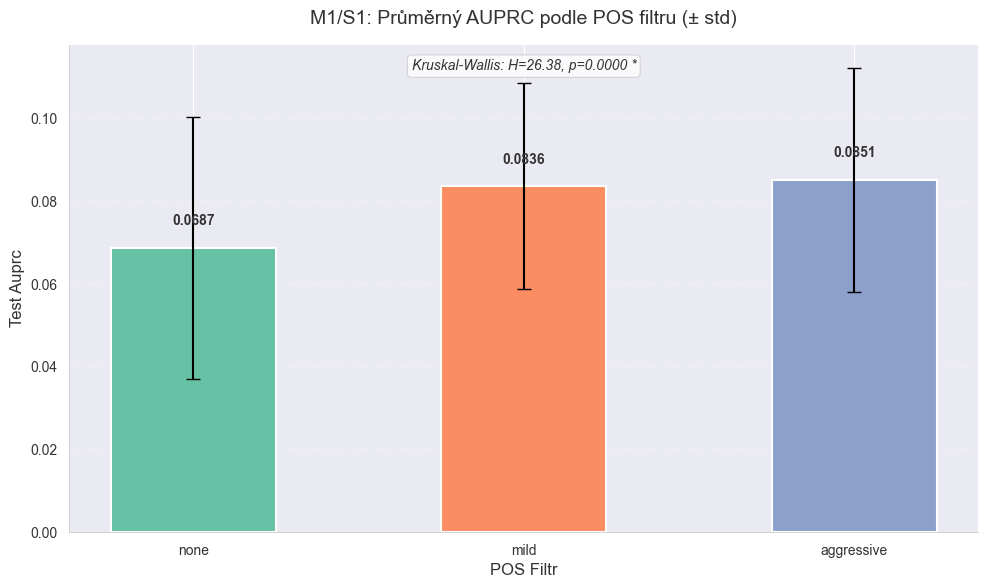

In [12]:
# --- Souhrnný barplot s Kruskal-Wallis anotací ---
visualization.plot_kruskal_posthoc_summary(
    df_m1, metric_col='test_auprc', filter_col='filter',
    filter_order=filter_order,
    title='M1/S1: Průměrný AUPRC podle POS filtru (± std)',
    save_path=RESULTS_DIR / "M1_S1_Filter_KW_Summary.png"
)

## 8. Statistické testování — Kruskal-Wallis + Post-Hoc

- **Kruskal-Wallis H-test**: Neparametrická obdoba ANOVA — testuje, zda se alespoň dvě skupiny liší.
- **Post-hoc Mann-Whitney U**: Párové srovnání aggressive vs none (pokud KW je signifikantní).

In [13]:
# Rozdělení AUPRC podle filtru
auprc_none = df_m1[df_m1['filter'] == 'none']['test_auprc'].values
auprc_mild = df_m1[df_m1['filter'] == 'mild']['test_auprc'].values
auprc_aggressive = df_m1[df_m1['filter'] == 'aggressive']['test_auprc'].values

print(f"Skupiny: none (n={len(auprc_none)}), mild (n={len(auprc_mild)}), aggressive (n={len(auprc_aggressive)})")
print()

# --- Kruskal-Wallis H-test ---
h_stat, p_kw = stats.kruskal(auprc_none, auprc_mild, auprc_aggressive)
print("=" * 60)
print("KRUSKAL-WALLIS H-TEST (AUPRC ~ filtr)")
print("=" * 60)
print(f"  H-statistika: {h_stat:.4f}")
print(f"  p-value:      {p_kw:.4f}")
print(f"  Signifikantní (α=0.05): {'✅ ANO' if p_kw < 0.05 else '❌ NE'}")
print()

# --- Post-hoc: Mann-Whitney U (aggressive vs none) ---
if p_kw < 0.05:
    print("→ KW je signifikantní, provádíme post-hoc Mann-Whitney U testy:")
    print()
    
    pairs = [
        ('aggressive', 'none', auprc_aggressive, auprc_none),
        ('aggressive', 'mild', auprc_aggressive, auprc_mild),
        ('mild', 'none', auprc_mild, auprc_none),
    ]
    
    posthoc_results = []
    for name1, name2, g1, g2 in pairs:
        u_stat, p_mw = stats.mannwhitneyu(g1, g2, alternative='greater')
        sig = '✅ ANO' if p_mw < 0.05 else '❌ NE'
        print(f"  {name1} vs {name2}: U={u_stat:.1f}, p={p_mw:.4f} → {sig}")
        posthoc_results.append({
            'Comparison': f'{name1} vs {name2}',
            'U_statistic': round(u_stat, 2),
            'p_value': round(p_mw, 4),
            'Significant': p_mw < 0.05,
        })
    
    df_posthoc = pd.DataFrame(posthoc_results)
    print()
    df_posthoc
else:
    print("→ KW NENÍ signifikantní — post-hoc testy nejsou potřeba.")
    df_posthoc = pd.DataFrame()

Skupiny: none (n=70), mild (n=70), aggressive (n=71)

KRUSKAL-WALLIS H-TEST (AUPRC ~ filtr)
  H-statistika: 26.3801
  p-value:      0.0000
  Signifikantní (α=0.05): ✅ ANO

→ KW je signifikantní, provádíme post-hoc Mann-Whitney U testy:

  aggressive vs none: U=3572.0, p=0.0000 → ✅ ANO
  aggressive vs mild: U=2552.0, p=0.3920 → ❌ NE
  mild vs none: U=3506.0, p=0.0000 → ✅ ANO



## 9. Srovnání M1/S1 (Unsupervised) vs M3/S1 (LLM) — Kontextová tabulka

In [14]:
# --- Agregované M1/S1 výsledky podle filtru ---
m1_agg = df_m1.groupby('filter').agg(
    AUPRC_mean=('test_auprc', 'mean'),
    AUPRC_std=('test_auprc', 'std'),
    F1_mean=('test_f1', 'mean'),
    F1_std=('test_f1', 'std'),
).round(4)
m1_agg['Source'] = 'M1/S1 (Unsupervised)'
m1_agg = m1_agg.reset_index().rename(columns={'filter': 'Filter'})

# --- LLM metriky ---
df_llm = pd.read_csv(RESULTS_DIR / "M3_S1_LLM_Metrics.csv")
llm_agg = df_llm[['model', 'filter', 'auprc', 'f1']].copy()
llm_agg = llm_agg.rename(columns={'model': 'Model', 'filter': 'Filter', 'auprc': 'AUPRC_mean', 'f1': 'F1_mean'})
llm_agg['AUPRC_std'] = np.nan
llm_agg['F1_std'] = np.nan
llm_agg['Source'] = 'M3/S1 (LLM)'

# Srovnávací tabulka
print("=" * 80)
print("SROVNÁNÍ: M1/S1 (Unsupervised, agregováno) vs M3/S1 (LLM)")
print("=" * 80)
print()
print("--- M1/S1 Unsupervised (průměr přes modely a scénáře) ---")
print(m1_agg[['Filter', 'AUPRC_mean', 'AUPRC_std', 'F1_mean', 'F1_std']].to_string(index=False))
print()
print("--- M3/S1 LLM (Gemma 3 27B) ---")
print(llm_agg[['Model', 'Filter', 'AUPRC_mean', 'F1_mean']].to_string(index=False))

SROVNÁNÍ: M1/S1 (Unsupervised, agregováno) vs M3/S1 (LLM)

--- M1/S1 Unsupervised (průměr přes modely a scénáře) ---
    Filter  AUPRC_mean  AUPRC_std  F1_mean  F1_std
aggressive      0.0851     0.0271   0.1010  0.0417
      mild      0.0836     0.0249   0.0927  0.0419
      none      0.0687     0.0317   0.0861  0.0445

--- M3/S1 LLM (Gemma 3 27B) ---
                                Model     Filter  AUPRC_mean  F1_mean
      Gemma 3 (27B) (Zero-Shot, None)       none    0.090166 0.182178
      Gemma 3 (27B) (Zero-Shot, Mild)       mild    0.116998 0.227848
Gemma 3 (27B) (Zero-Shot, Aggressive) aggressive    0.129715 0.240964
       Gemma 3 (27B) (Few-Shot, None)       none    0.102545 0.210526
       Gemma 3 (27B) (Few-Shot, Mild)       mild    0.132978 0.261398
 Gemma 3 (27B) (Few-Shot, Aggressive) aggressive    0.151969 0.280576
                         Dummy (None)       none    0.048957 0.000000
                         Dummy (Mild)       mild    0.065005 0.000000
                